# Sakina — Brain Response to Quran Recitation

Visualize how the brain responds to Surah Al-Fatiha using Meta's TRIBE v2 model.

**Setup**: Run the first cell, restart runtime, then run all cells.

In [8]:
!pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
from tribev2.demo_utils import TribeModel
from tribev2.plotting import PlotBrain
from pathlib import Path
import numpy as np

CACHE = Path('./cache')
model = TribeModel.from_pretrained('facebook/tribev2', cache_folder=CACHE)
plotter = PlotBrain(mesh='fsaverage5')
print('Model loaded!')

/home/openclaw-agent/.local/lib/python3.12/site-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-03-30 07:31:26 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
/home/openclaw-agent/.local/lib/python3.12/site-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-03-30 07:31:28 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class

Model loaded!


In [3]:
# Download Al-Fatiha recitation
import urllib.request
CACHE.mkdir(exist_ok=True)
url = 'https://download.quranicaudio.com/qdc/mishari_al_afasy/murattal/1.mp3'
audio_path = CACHE / 'al-fatiha.mp3'
if not audio_path.exists():
    urllib.request.urlretrieve(url, audio_path)
print(f'Audio: {audio_path} ({audio_path.stat().st_size / 1024:.0f} KB)')

Audio: cache/al-fatiha.mp3 (775 KB)


In [4]:
# Process audio and predict brain response
import pandas as pd
from tribev2.demo_utils import get_audio_and_text_events

event = {'type': 'Audio', 'filepath': str(audio_path), 'start': 0, 'timeline': 'default', 'subject': 'default'}
events = get_audio_and_text_events(pd.DataFrame([event]), audio_only=True)
print(f'Events: {len(events)} rows')

preds, segments = model.predict(events=events)
print(f'Predictions: {preds.shape} ({preds.shape[0]} timesteps × {preds.shape[1]} vertices)')

[07:31:30 WARNING] Removing extractor video as there are no corresponding events
[07:31:30 WARNING] Removing extractor text as there are no corresponding events
[07:31:30 INFO] Preparing extractor: audio


Events: 1 rows


Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[07:31:38 INFO] Preparing extractor: subject_id
2026-03-30 07:31:38 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[07:31:38 INFO] Building dataloader for split all
100%|██████████| 1/1 [00:00<00:00,  1.28it/s]
INFO - Predicted 47 / 100 segments (47.0% kept)


Predictions: (47, 20484) (47 timesteps × 20484 vertices)


Plotting...: 100%|██████████| 15/15 [00:02<00:00,  6.35it/s]


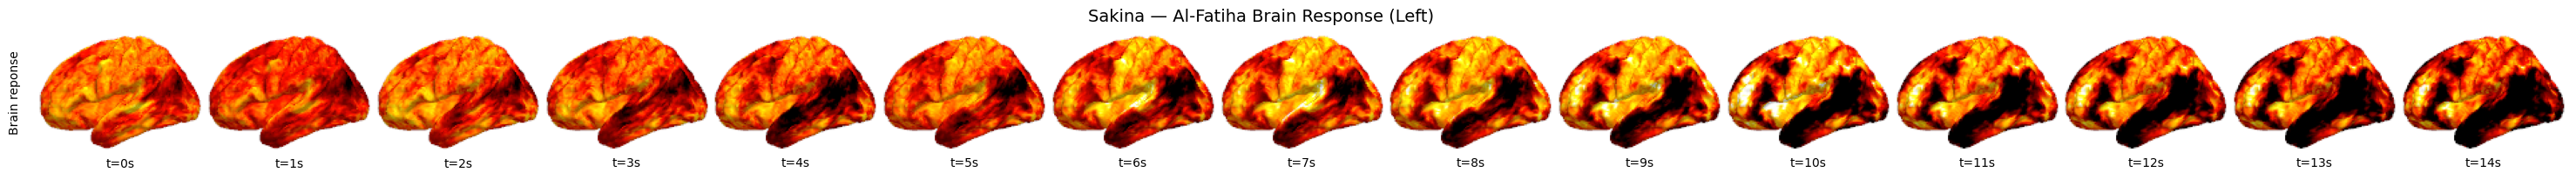

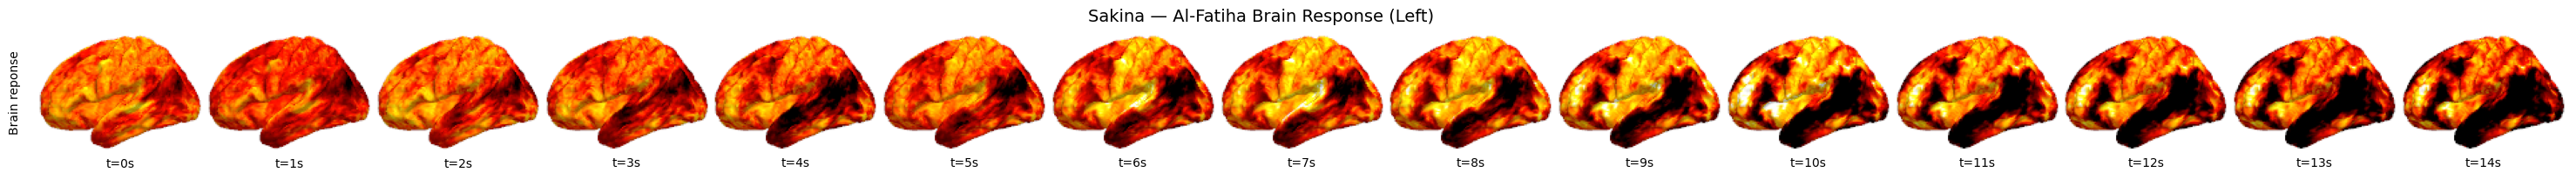

In [5]:
# Visualize brain response — left hemisphere
fig = plotter.plot_timesteps(preds[:15], cmap='fire', norm_percentile=99, vmin=0.3, views='left')
fig.suptitle('Sakina — Al-Fatiha Brain Response (Left)', fontsize=14)
fig

Plotting...: 100%|██████████| 15/15 [00:02<00:00,  7.29it/s]


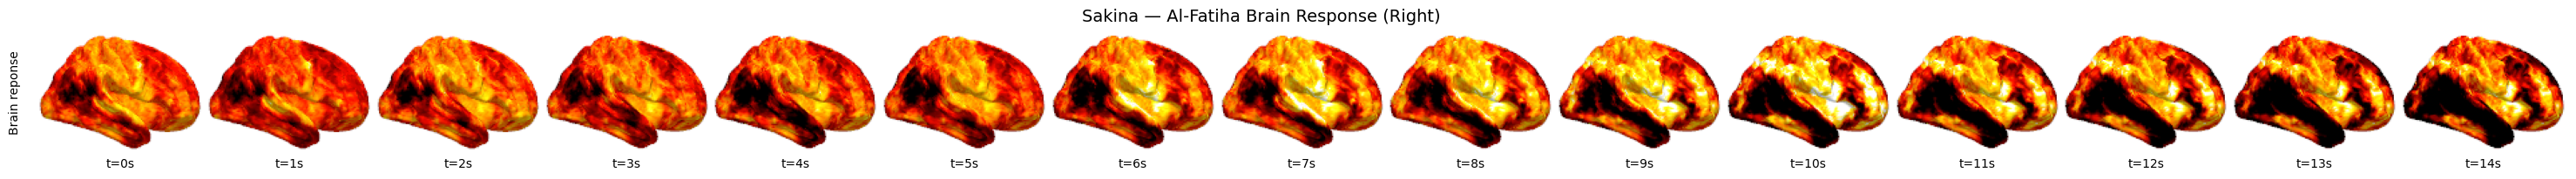

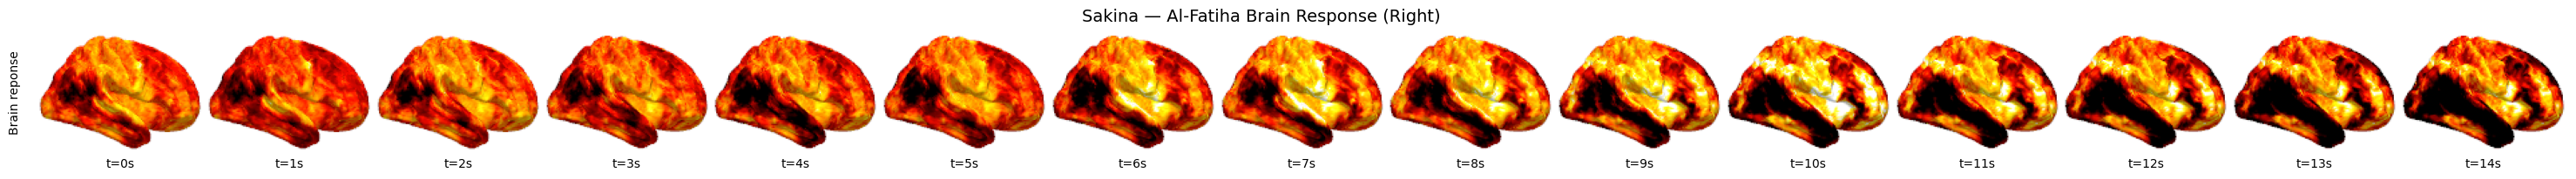

In [6]:
# Right hemisphere
fig2 = plotter.plot_timesteps(preds[:15], cmap='fire', norm_percentile=99, vmin=0.3, views='right')
fig2.suptitle('Sakina — Al-Fatiha Brain Response (Right)', fontsize=14)
fig2

Plotting...: 100%|██████████| 15/15 [00:02<00:00,  6.66it/s]


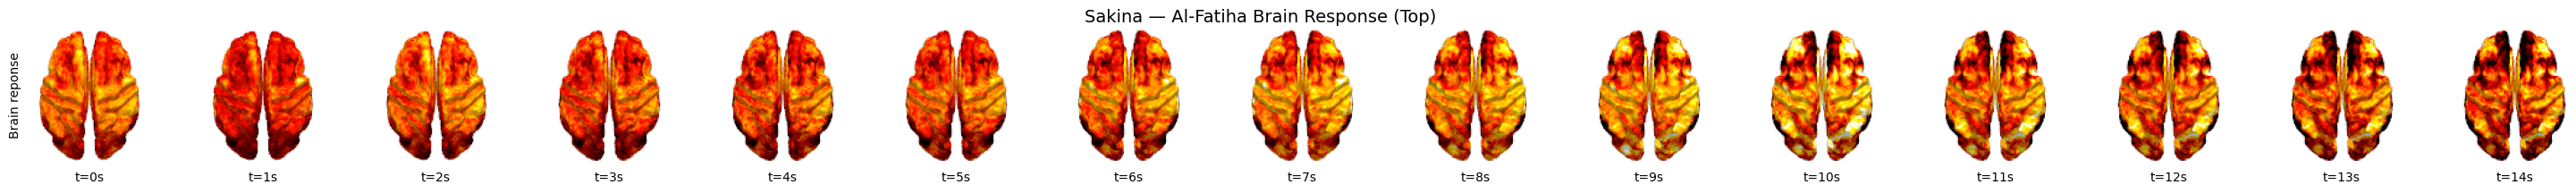

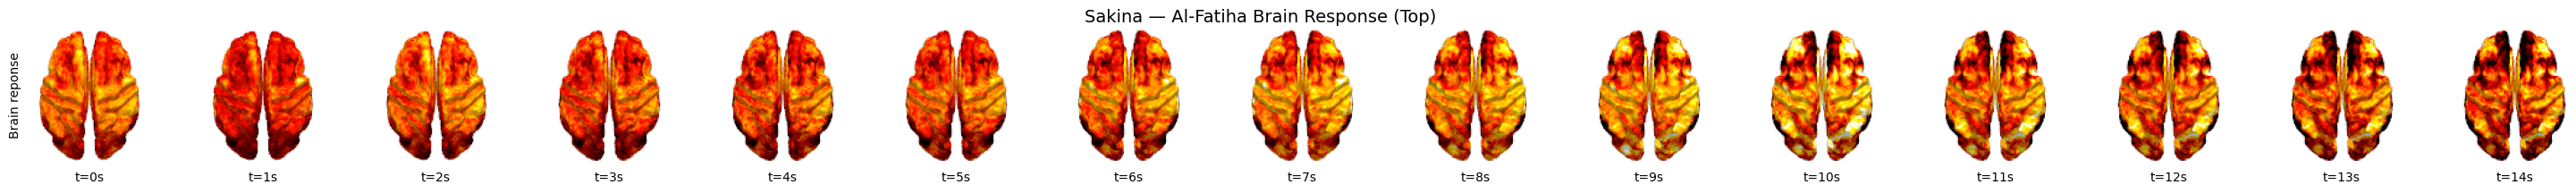

In [7]:
# Top view
fig3 = plotter.plot_timesteps(preds[:15], cmap='fire', norm_percentile=99, vmin=0.3, views='dorsal')
fig3.suptitle('Sakina — Al-Fatiha Brain Response (Top)', fontsize=14)
fig3